# Linear Regression with Neural Networks

<a href="https://colab.research.google.com/github/HassanAlgoz/dl/blob/main/modules/deep-learning/02-lab_nn/lab_nn_regression.ipynb" target="_blank">
  <img src="https://raw.githubusercontent.com/HassanAlgoz/dl/main/assets/Open%20in%20Colab-F9AB00.svg" alt="Open in Colab" height="50"/>
</a>

Train a neural network to predict a continuous value from an input.

You'll generate noisy points along the line `y = 3x + 2`, fit an `MLPRegressor` with **no hidden layer**, and check that it recovers the slope and intercept.


In [1]:
# --- Setup: Clone repo & cd into correct folder (Colab only) ---
import os
import sys
import subprocess

if "google.colab" in sys.modules:
    repo_url = "https://github.com/HassanAlgoz/dl.git"
    lab_folder = "dl/modules/deep-learning/02-lab_nn"

    # Only clone if the folder doesn't exist
    if not os.path.exists(lab_folder):
        subprocess.run(["git", "clone", repo_url])

    # Change working directory to the lab folder
    os.chdir(lab_folder)


## Imports

- **`pandas`**: hold features in a DataFrame with named columns
- **`numpy`**: generate the synthetic points
- **`MLPRegressor`**: a neural network for predicting a continuous value

This lab predicts a number, so you'll use [`MLPRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html). For a class label, scikit-learn has [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).


In [2]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor

import helper_utils


## The Regression Problem

The true relationship is a straight line:

`y = 3x + 2`

You'll only see noisy observations. A single linear neuron should recover a weight near **3** and a bias near **2**.


## Generate Data

Build 100 random points.

* `X`: a DataFrame with one column, `x` (2D — what scikit-learn expects for features)
* `y`: the noisy target (1D — what `MLPRegressor` expects for a single output)


In [3]:
rng = np.random.default_rng(42)
x_values = rng.normal(size=100)

X = pd.DataFrame({"x": x_values})
y = 3 * X["x"] + 2 + rng.normal(size=100) * 0.5

X.head()


,x
0,0.304717
1,-1.039984
2,0.750451
3,0.940565
4,-1.951035


In [4]:
y.head()


0    2.725070
1   -0.470338
2    4.073222
3    5.190452
4   -4.319914
Name: x, dtype: float64

The points follow a **straight line**, with a little scatter around it.


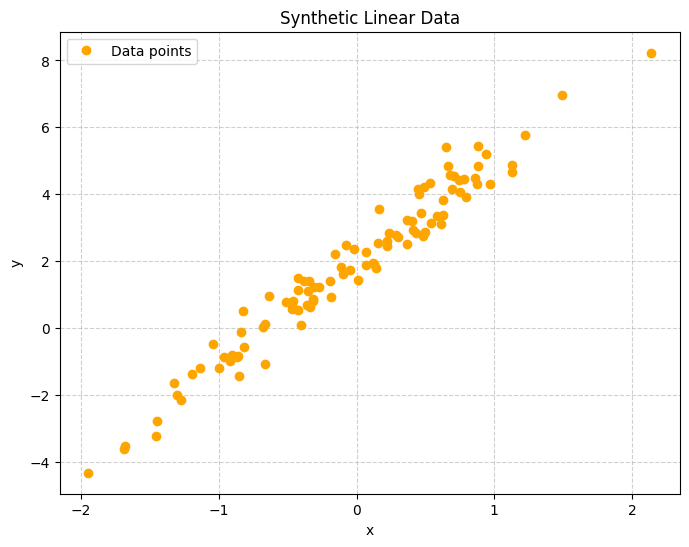

In [5]:
helper_utils.plot_regression_data(X, y, title="Synthetic Linear Data")


## A Simple Linear Neural Network

A single linear neuron predicts `y ≈ weight × x + bias`.

In scikit-learn, that's an `MLPRegressor` with:

* **`hidden_layer_sizes=()`**: no hidden layer — input straight to output
* **`activation="identity"`**: no extra non-linearity (the output is a straight line)
* **`solver="lbfgs"`**: a good default on tiny datasets
* **`random_state=42`**: reproducible weight initialization

We're skipping feature scaling so you can read the learned weight as "units of y per unit of x" and the bias as the intercept.


In [6]:
model = MLPRegressor(
    hidden_layer_sizes=(),
    activation="identity",
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)


## Training

Training is a single call: `model.fit(X, y)`.

`MLPRegressor` minimizes **squared error** — how far predicted values are from actual values — and updates the weight and bias. You don't write a training loop yourself.


In [7]:
model.fit(X, y)

print("Training complete.")


Training complete.


## Visualize

Plot the data against the learned line:


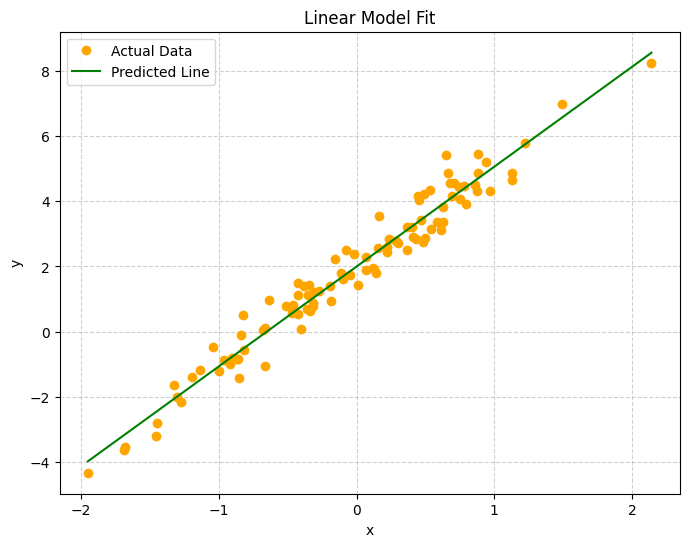

In [8]:
helper_utils.plot_fit(
    model,
    X,
    y,
    title="Linear Model Fit",
    pred_label="Predicted Line",
)


## Inspect Parameters

With no hidden layer, `coefs_[0]` is the input-to-output weight and `intercepts_[0]` is the bias.


In [9]:
weight = model.coefs_[0].item()
bias = model.intercepts_[0].item()

print(f"Weight: {weight:.2f}")
print(f"Bias: {bias:.2f}")


Weight: 3.06
Bias: 2.00


**Interpretation**

- **Weight (~3.0):** slope of the line — how much `y` changes when `x` increases by 1
- **Bias (~2.0):** intercept — the value of `y` when `x` is 0

The network recovered `y ≈ 3x + 2` from the noisy points.


## Predict

Predict `y` for a new `x`. Pass a one-row DataFrame with the same column name used in training.


In [10]:
new_x = pd.DataFrame({"x": [1.5]})
predicted_y = model.predict(new_x)[0]

print(f"Prediction for x = 1.5: {predicted_y:.2f}")
print(f"True line at x = 1.5: {3 * 1.5 + 2:.2f}")


Prediction for x = 1.5: 6.59
True line at x = 1.5: 6.50


## Two Input Features

The same linear neuron works with more than one input. Generate data from

`y = 3 × x1 + 2 × x2 + 2`

and train an `MLPRegressor` with two columns. The two weights should land near **3** and **2**, and the bias near **2**.


In [11]:
rng = np.random.default_rng(42)
raw = rng.normal(size=(100, 2))

X2 = pd.DataFrame(raw, columns=["x1", "x2"])
y2 = 3 * X2["x1"] + 2 * X2["x2"] + 2 + rng.normal(size=100) * 0.1

model2 = MLPRegressor(
    hidden_layer_sizes=(),
    activation="identity",
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)
model2.fit(X2, y2)

weights = model2.coefs_[0].ravel()
bias2 = model2.intercepts_[0].item()

print(f"Weights: {weights[0]:.2f}, {weights[1]:.2f}")
print(f"Bias: {bias2:.2f}")


Weights: 2.99, 2.00
Bias: 1.99


## Conclusion

A one-neuron linear network recovered the slope and intercept of noisy line data. With two features it recovered both weights.

`MLPRegressor` added the output layer and trained with `.fit()` — no epoch loop, loss function, or optimizer to write by hand. `hidden_layer_sizes=()` and `activation="identity"` keep the model a straight line.

Up next: classification — [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) instead of `MLPRegressor` — and decision boundaries in 2D.

See scikit-learn's [neural network models (supervised)](https://scikit-learn.org/stable/modules/neural_networks_supervised.html) guide and the [`MLPRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) docs.
